In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import InMemorySaver


In [2]:
class state(TypedDict):

    message : Annotated[list[BaseMessage],add_messages]

In [3]:
model=ChatOllama(
    model='llama3.2:3b',
    reasoning=False
)
def chat(state:state):
    res=model.invoke(state['message'])
    return {'message': res}


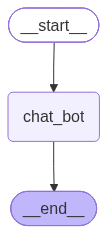

In [8]:
check=InMemorySaver()
graph=StateGraph(state)

graph.add_node('chat_bot',chat)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

workflow=graph.compile(checkpointer=check)

workflow

In [5]:
intial_state={'message':[HumanMessage(content="what is the capital of india")]}
workflow.invoke(intial_state)

{'message': [HumanMessage(content='what is the capital of india', additional_kwargs={}, response_metadata={}, id='c8a2036f-f638-49a8-9550-37f4de78e05a'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-07-29T03:46:50.8292465Z', 'done': True, 'done_reason': 'stop', 'total_duration': 22331150400, 'load_duration': 21622185800, 'prompt_eval_count': 31, 'prompt_eval_duration': 360048000, 'eval_count': 9, 'eval_duration': 313711000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019fabfb-1c01-7011-a4d7-06e01bb416a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 9, 'total_tokens': 40})]}

In [10]:
thred_id="1"
while True:
    user_input=input("enter the msg:")
    print("user :",user_input)
    if user_input.strip().lower() in ['braek','bye','exit']:
        break
    config={'configurable':{'thread_id': thred_id}}
    response=workflow.invoke({'message':[HumanMessage(content=user_input)]},config=config)
    print("ai :",response['message'][-1].content)

user : hi
ai : How can I assist you today?
user : my name is sarthak
ai : Nice to meet you, Sarthak! Is there something I can help you with or would you like to chat for a bit?
user : what is my name 
ai : Your name is Sarthak. We've been chatting about it already!
user : add 3 and 6
ai : Easy math problem!

The answer to 3 + 6 is: 9
user : now add result into 10
ai : You want me to add 9 to 10.

The answer is: 19
user : bye


In [11]:
workflow.get_state(config)

StateSnapshot(values={'message': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='c324f202-0aba-43d2-a099-8e2cd6a1e30b'), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-07-29T03:56:07.8792304Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12465246500, 'load_duration': 11952176200, 'prompt_eval_count': 26, 'prompt_eval_duration': 257595000, 'eval_count': 8, 'eval_duration': 240672000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019fac03-c292-7fe0-a8bf-a4d9ff4d74a2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34}), HumanMessage(content='my name is sarthak', additional_kwargs={}, response_metadata={}, id='417c85dd-9ea0-4b7a-b345-463ce65d3c1e'), AIMessage(content='Nice to meet you, Sarthak! Is there something I can help you with or would you like to chat f